# Turbofan Engine RUL Prediction — Main Analysis
Regression: predict Remaining Useful Life (RUL, in cycles) for NASA C-MAPSS turbofan engines (subset FD001) from a windowed sequence of 15 sensor readings. Pipeline: audit -> preprocess (label capping, unit-level split, scaling, windowing) -> linear baselines -> LSTM -> window-length ablation -> evaluation -> interpretation.

## Setup
Imports and adds `../src` to the path to reuse the pipeline modules directly.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
from IPython.display import Image, display

from preprocess import (
    FEATURE_COLS, WINDOW_SIZE, RUL_CAP, load_raw, prepare_data,
    TRAIN_PATH, TEST_PATH, RUL_PATH,
)
from baselines import train_cycle_only_baseline, train_snapshot_baseline
from train import train_model
from evaluate import (
    rmse, mae, phm_score, rul_band_error, permutation_importance_lstm,
    lstm_predict, plot_pred_vs_actual, plot_training_curves,
    plot_rul_band_error, plot_permutation_importance, plot_sample_trajectories,
)

%matplotlib inline

## 1. Data Audit
Shape, trajectory lengths, constant sensors/operating settings, and the train/test structural difference (train units run to failure; test trajectories are truncated before failure, with ground-truth RUL given separately).

In [2]:
raw_train = load_raw(TRAIN_PATH)
raw_test = load_raw(TEST_PATH)
test_rul = pd.read_csv(RUL_PATH, header=None, names=['RUL'])['RUL']

print(f"Train: {raw_train.shape}, units={raw_train['unit'].nunique()}")
print(f"Test:  {raw_test.shape}, units={raw_test['unit'].nunique()}")
print(f"Train cycles/unit: min={raw_train.groupby('unit').size().min()}, "
      f"max={raw_train.groupby('unit').size().max()}")
print(f"Test cycles/unit:  min={raw_test.groupby('unit').size().min()}, "
      f"max={raw_test.groupby('unit').size().max()}")
print(f"\nOperating-setting std (train) -- confirms single operating "
      f"condition in FD001:")
print(raw_train[['op1', 'op2', 'op3']].std())

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
stds = raw_train[sensor_cols].std()
print(f"\nConstant sensors (std < 1e-3), dropped as zero-information:")
print(stds[stds < 1e-3])
print(f"\nRemaining feature count: {len(FEATURE_COLS)}")

Train: (20631, 26), units=100
Test:  (13096, 26), units=100
Train cycles/unit: min=128, max=362
Test cycles/unit:  min=31, max=303

Operating-setting std (train) -- confirms single operating condition in FD001:
op1    0.002187
op2    0.000293
op3    0.000000
dtype: float64

Constant sensors (std < 1e-3), dropped as zero-information:
sensor_1     0.000000e+00
sensor_5     5.329200e-15
sensor_10    0.000000e+00
sensor_16    3.469531e-18
sensor_18    0.000000e+00
sensor_19    0.000000e+00
dtype: float64

Remaining feature count: 15


## 2. Preprocessing
- **RUL capping**: train target = `min(max_cycle(unit) - t, 125)` -- early-life cycles carry no degradation signal, so capping focuses the model on the informative near-failure region (standard practice).
- **Unit-level split**: 80/20 train/val split on *engine unit*, not row -- adjacent windows from the same engine overlap by up to 29/30 timesteps, so a row-level split would leak near-duplicates across train/val.
- **Scaling**: `StandardScaler` fit on the 80 train units' rows only, applied to val and test.
- **Windowing**: sliding windows of length 30 (stride 1) per unit; the minimum test trajectory is 31 cycles, so every test unit yields one full window with no padding needed on this subset.

In [3]:
data = prepare_data()
print(f"Train windows: {data['X_train_seq'].shape}")
print(f"Val windows:   {data['X_val_seq'].shape}")
print(f"Test windows:  {data['X_test_seq'].shape}")
print(f"Train/val units disjoint: {data['train_units'].isdisjoint(data['val_units'])}")
print(f"Train units: {len(data['train_units'])}, Val units: {len(data['val_units'])}")

Train windows: (14241, 30, 15)
Val windows:   (3490, 30, 15)
Test windows:  (100, 30, 15)
Train/val units disjoint: True
Train units: 80, Val units: 20


## 3. Baselines — Linear Regression
Two linear baselines, both with **no sequence access** (current-cycle snapshot only): the full 15-feature snapshot, and a trivial cycle-count-only regression (mirrors "no single feature/no history is sufficient").

In [4]:
lr_snap = train_snapshot_baseline(data['X_train_snap'], data['y_train_snap'])
lr_cycle = train_cycle_only_baseline(data['cycle_train_snap'], data['y_train_snap'])

preds_snap = lr_snap.predict(data['X_test_snap'])
preds_cycle = lr_cycle.predict(data['cycle_test_snap'])

print(f"Linear (cycle only): RMSE={rmse(data['y_test'], preds_cycle):.2f}")
print(f"Linear (snapshot):   RMSE={rmse(data['y_test'], preds_snap):.2f}")

Linear (cycle only): RMSE=32.31
Linear (snapshot):   RMSE=20.77


## 4. LSTM Training
`LSTM(15 -> hidden=64) -> Dropout -> Linear(64->32) -> ReLU -> Dropout -> Linear(32->1)`, MSE loss, Adam, early stopping on validation loss. Unlike the linear baselines, the LSTM sees the full 30-cycle window -- the head-to-head comparison isolates the value of temporal context, since both share the same scaled 15-feature space.

In [5]:
lstm_main, hist_main = train_model(
    data['X_train_seq'], data['y_train_seq'], data['X_val_seq'], data['y_val_seq'],
    input_dim=len(data['feature_cols']),
)
preds_lstm = lstm_predict(lstm_main, data['X_test_seq'])

print(f"Epochs trained: {len(hist_main['train_loss'])}")
print(f"LSTM (window=30): RMSE={rmse(data['y_test'], preds_lstm):.2f}")

Epochs trained: 29
LSTM (window=30): RMSE=12.64


## 5. Window-Length Ablation
Window=30 was chosen because it is the largest window that still leaves a 1-cycle margin under the shortest test trajectory (31 cycles). Validating that choice empirically against a shorter window (15), trained and evaluated identically.

In [6]:
data_w15 = prepare_data(window_size=15)
lstm_w15, hist_w15 = train_model(
    data_w15['X_train_seq'], data_w15['y_train_seq'],
    data_w15['X_val_seq'], data_w15['y_val_seq'],
    input_dim=len(data['feature_cols']),
)
preds_lstm_w15 = lstm_predict(lstm_w15, data_w15['X_test_seq'])

print(f"LSTM (window=15): RMSE={rmse(data['y_test'], preds_lstm_w15):.2f} "
      f"(vs {rmse(data['y_test'], preds_lstm):.2f} for window=30)")

LSTM (window=15): RMSE=15.79 (vs 12.64 for window=30)


## 6. Evaluation — Comparison Table
RMSE, MAE, and the NASA/PHM08 asymmetric score (penalizes late/dangerous overestimates of remaining life more heavily than early/conservative underestimates) for all four models.

In [7]:
def summarize(y_true, y_pred):
    s = phm_score(y_true, y_pred)
    return {'RMSE': rmse(y_true, y_pred), 'MAE': mae(y_true, y_pred),
            'PHM score (total)': s['total'], 'PHM score (mean)': s['mean']}

results = {
    'Linear (cycle only)': summarize(data['y_test'], preds_cycle),
    'Linear (snapshot)': summarize(data['y_test'], preds_snap),
    'LSTM (window=30, main model)': summarize(data['y_test'], preds_lstm),
    'LSTM (window=15, ablation)': summarize(data['y_test'], preds_lstm_w15),
}
pd.DataFrame(results).T.round(2)

,RMSE,MAE,PHM score (total),PHM score (mean)
Linear (cycle only),32.31,26.57,5080.11,50.80
Linear (snapshot),20.77,16.55,1238.81,12.39
"LSTM (window=30, main model)",12.64,9.65,271.43,2.71
"LSTM (window=15, ablation)",15.79,11.02,553.61,5.54


## 7. Evaluation — Plots
Predicted vs. true RUL, training curves (both window lengths), and sample per-engine RUL trajectories (true RUL is reconstructed from the one given ground-truth value, since RUL decreases by exactly 1/cycle).

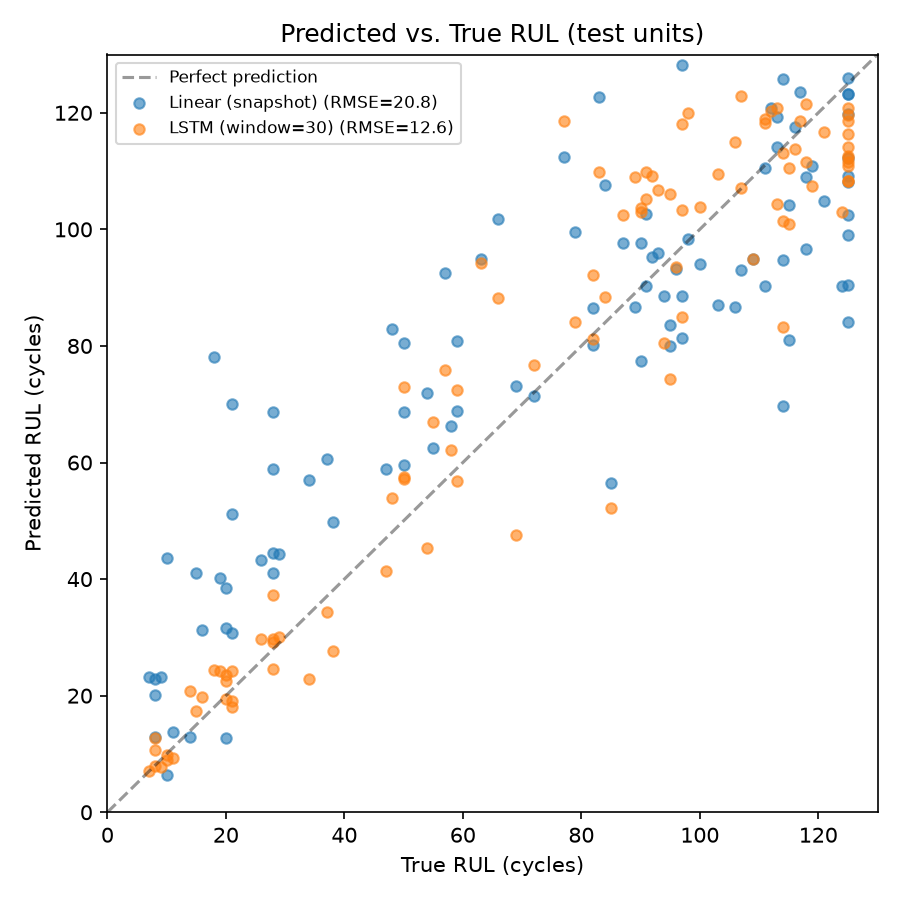

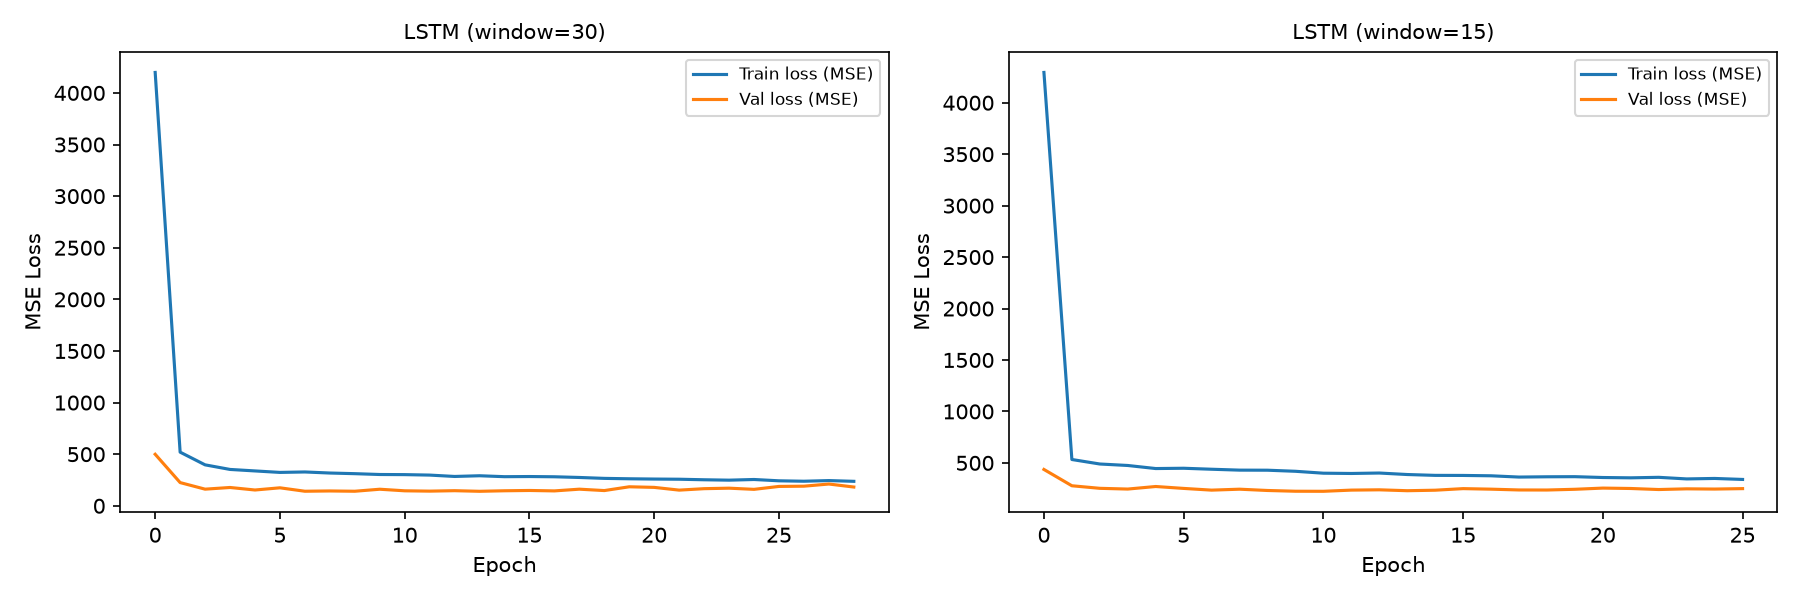

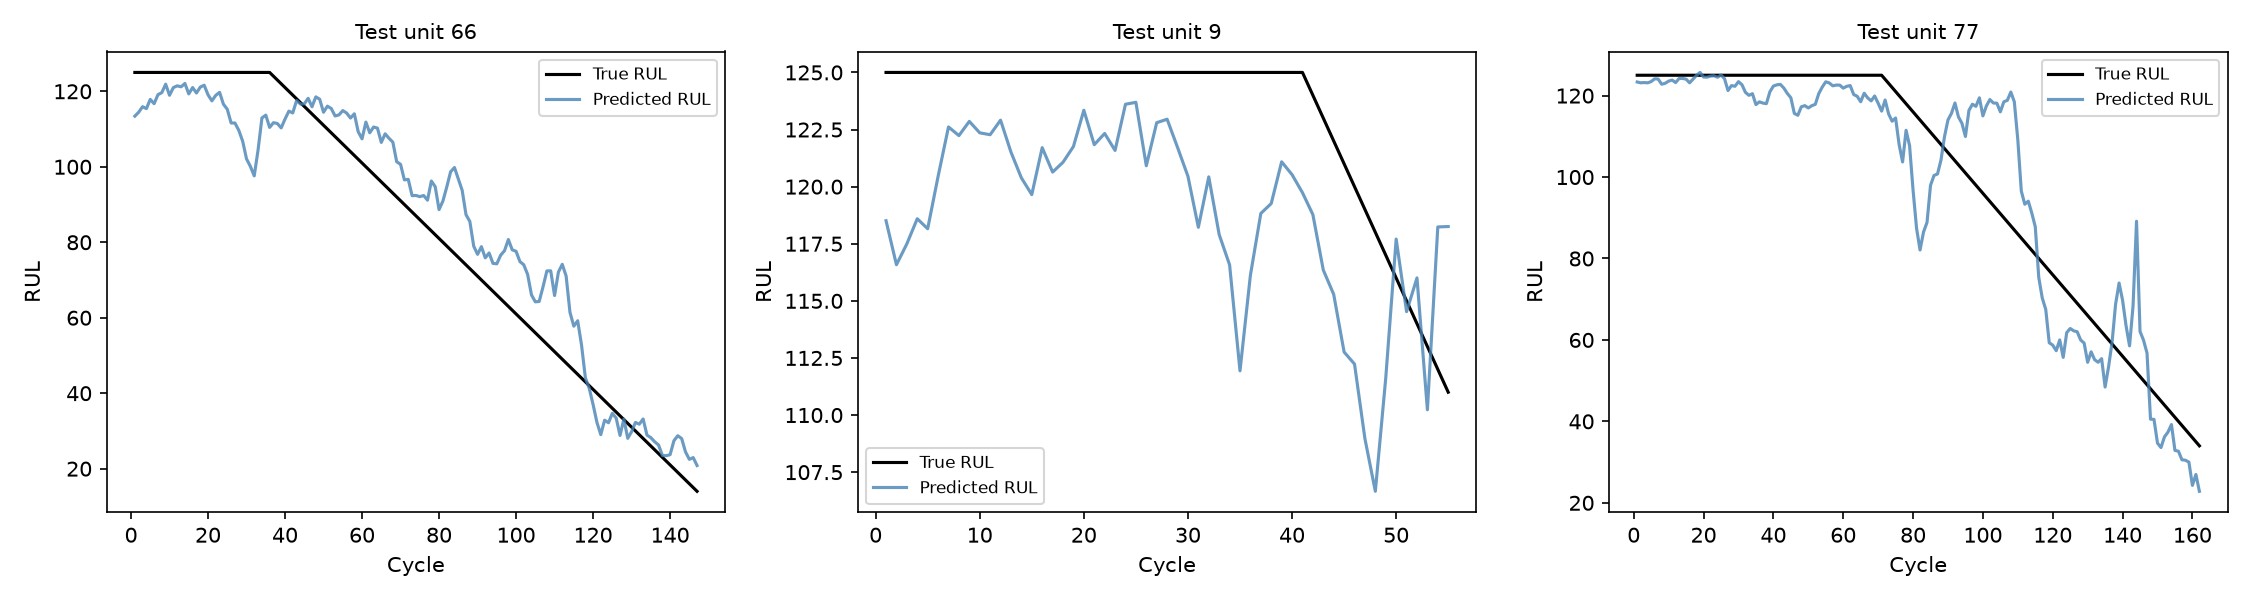

In [8]:
plot_pred_vs_actual(
    {'Linear (snapshot)': {'y_true': data['y_test'], 'y_pred': preds_snap, 'rmse': rmse(data['y_test'], preds_snap)},
     'LSTM (window=30)': {'y_true': data['y_test'], 'y_pred': preds_lstm, 'rmse': rmse(data['y_test'], preds_lstm)}},
    '../outputs/figures/pred_vs_actual.png',
)
plot_training_curves(
    {'LSTM (window=30)': hist_main, 'LSTM (window=15)': hist_w15},
    '../outputs/figures/training_curves.png',
)
plot_sample_trajectories(lstm_main, data, '../outputs/figures/sample_trajectories.png')

display(Image('../outputs/figures/pred_vs_actual.png'))
display(Image('../outputs/figures/training_curves.png'))
display(Image('../outputs/figures/sample_trajectories.png'))

## 8. Interpretation — Permutation Importance
For each sensor channel, shuffle its full time series across the batch dimension (preserving within-window temporal structure) and measure the RMSE *increase* -- a larger increase means the model relies more on that channel.

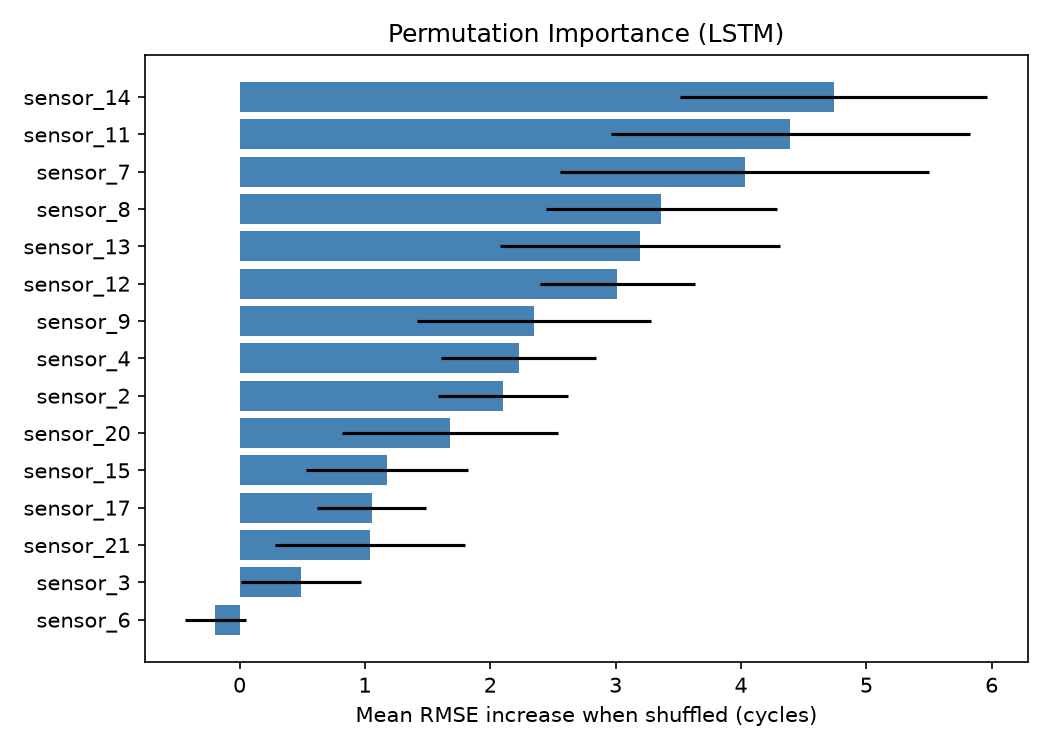

,mean,std
sensor_14,4.739,1.227
sensor_11,4.394,1.432
sensor_7,4.030,1.473
sensor_8,3.366,0.918
sensor_13,3.198,1.117
sensor_12,3.014,0.618
sensor_9,2.350,0.931
sensor_4,2.227,0.618
sensor_2,2.102,0.521
sensor_20,1.678,0.858


In [9]:
importances = permutation_importance_lstm(
    lstm_main, data['X_test_seq'], data['y_test'], rmse(data['y_test'], preds_lstm)
)
plot_permutation_importance(importances, '../outputs/figures/permutation_importance.png')
display(Image('../outputs/figures/permutation_importance.png'))

pd.DataFrame(importances).T.round(3).sort_values('mean', ascending=False)

## 9. Interpretation — RUL-Band Failure Case
LSTM error broken down by true-RUL band (cycles-to-failure), using fixed, operationally meaningful thresholds rather than statistical quartiles -- the near-failure band is the maintenance-critical one.

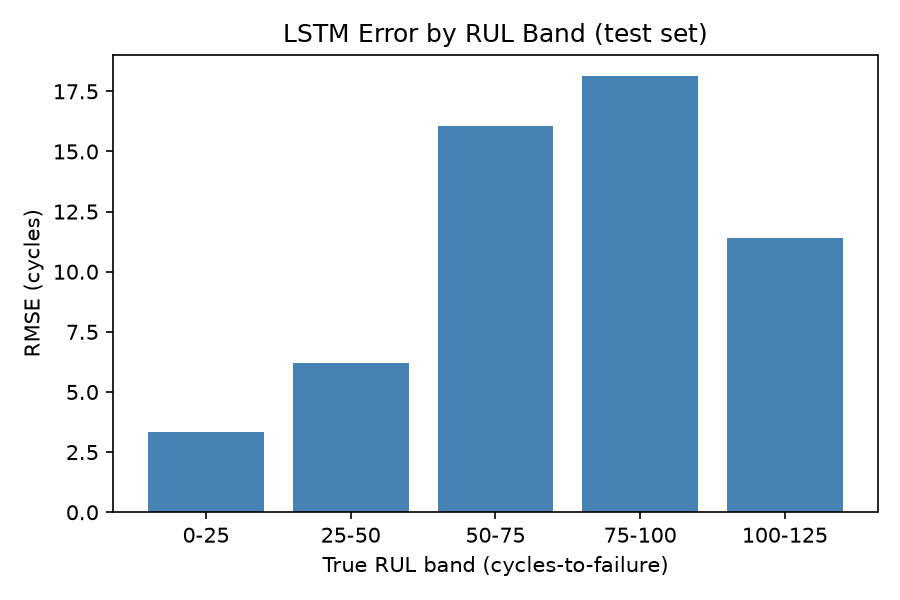

,band,n,rmse,mae
0,0-25,19,3.331344,2.676614
1,25-50,11,6.203777,5.095067
2,50-75,13,16.078720,13.580967
3,75-100,23,18.125868,15.514194
4,100-125,34,11.409989,9.546185


In [10]:
bands = rul_band_error(data['y_test'], preds_lstm)
plot_rul_band_error(bands, '../outputs/figures/rul_band_error.png')
display(Image('../outputs/figures/rul_band_error.png'))

pd.DataFrame(bands)

## 10. Conclusion
- The LSTM (window=30) achieves RMSE far below both linear baselines (cycle-only and full-snapshot). Because both models share identical preprocessing and feature space, this gap is directly attributable to the 30 cycles of degradation trend the LSTM can see that the linear baselines cannot.
- The window-length ablation confirms 30 beats 15 -- more temporal context measurably helps, validating the window-size choice rather than merely asserting it.
- Error is smallest in the near-failure RUL band (0-25 cycles-to-failure) -- the operationally critical region where accurate predictions matter most for maintenance scheduling.
- Permutation importance spreads across several sensors rather than being dominated by one, consistent with genuine multivariate degradation signal.
- See `report/exam3_report.pdf` for the full write-up, including problem relevance, data-choice audit, model-setup justification, limitations, and the "why this data/setup were the right choice" conclusion.